In [1]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
mpg = pd.read_csv('auto-mpg.csv')

In [3]:
mpg = mpg.dropna()
X = mpg[['horsepower']]
y = mpg['mpg']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)

In [17]:
degree = 2
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [18]:
print("\n--- Polynomial Regression (Auto MPG) ---")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


--- Polynomial Regression (Auto MPG) ---
MSE: 23.6075673175567
R2 Score: 0.5449821242512474


In [19]:
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_range_pred = model.predict(X_range)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


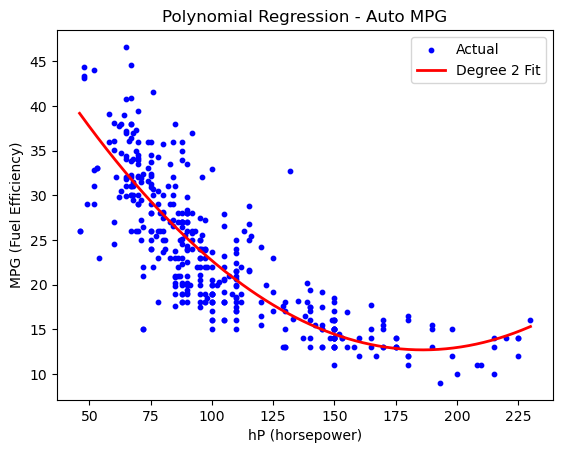

In [20]:
plt.scatter(X, y, color='blue', s=10, label='Actual')
plt.plot(X_range, y_range_pred, color='red', linewidth=2,
label=f'Degree {degree} Fit')
plt.ylabel('MPG (Fuel Efficiency)')
plt.xlabel('hP (horsepower)')
plt.title('Polynomial Regression - Auto MPG')
plt.legend()
plt.show()